<a href="https://colab.research.google.com/github/JosephBless/Deep-Learning-Colab/blob/main/Chap_3%EF%BC%9A%E6%95%B8%E6%93%9A%E6%B8%85%E6%B4%97%E3%80%81%E8%99%95%E7%90%86%E8%88%87%E8%B2%A1%E5%8B%99%E6%8C%87%E6%A8%99%E8%A8%88%E7%AE%97.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

今天我們將學習如何對金融數據進行清洗和處理，以及如何計算一些常用的財務和技術指標，這些指標將用於後續的策略分析與開發。

In [ ]:
# Colab 進行matplotlib繪圖時顯示繁體中文
# 下載台北思源黑體並命名taipei_sans_tc_beta.ttf，移至指定路徑
!wget -O TaipeiSansTCBeta-Regular.ttf https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download

import matplotlib

# 改style要在改font之前
# plt.style.use('seaborn')

matplotlib.font_manager.fontManager.addfont('TaipeiSansTCBeta-Regular.ttf')
matplotlib.rc('font', family='Taipei Sans TC Beta')

--2024-09-18 08:56:49--  https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.google.com (drive.google.com)... 172.217.218.113, 172.217.218.100, 172.217.218.102, ...
Connecting to drive.google.com (drive.google.com)|172.217.218.113|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_ [following]
--2024-09-18 08:56:50--  https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 173.194.69.132, 2a00:1450:4013:c04::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|173.194.69.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20659344 (20M) [application/octet-stream]
Saving to: ‘TaipeiSansTCBeta-Regular.ttf’

TaipeiSansTCBeta-Re 100%[===================>]  19.70M  77.0MB/s    in 0.3s    

2024-09-18 08

### 1. 數據清洗與處理

#### 1.1 處理缺失值
在金融數據中，缺失值是常見的問題。缺失值可能來自數據提供商的不完整信息，或者特定交易日無法獲取到數據。首先，我們需要處理這些缺失值。

In [ ]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# 使用 APPLE 股票當例子
stock_data = yf.download('AAPL', start='2022-01-01', end='2023-01-01')

# 檢查數據中是否有缺失值
print("\n")
print(stock_data.isnull().sum())

# 方法一：刪除缺失值
stock_data_cleaned = stock_data.dropna()

# 方法二：使用插值法填補缺失值
stock_data_filled = stock_data.fillna(method='ffill')  # 使用前一個有效數據填補

[*********************100%***********************]  1 of 1 completed



Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64



<ipython-input-15-f96545a3e6b3>:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  stock_data_filled = stock_data.fillna(method='ffill')  # 使用前一個有效數據填補


#### 1.2 處理重複數據
在清理數據時，我們還需要確保數據中沒有重複的記錄。重複數據可能會導致錯誤的分析結果。

In [ ]:
# 檢查重複數據
print(stock_data.duplicated().sum())

# 刪除重複數據
stock_data = stock_data.drop_duplicates()

0


#### 1.3 時間序列處理
金融數據通常是以時間序列的形式呈現。我們需要確保數據按照時間順序排列，並且時間索引是正確的。

In [ ]:
# 確認數據按時間順序排列
stock_data = stock_data.sort_index()

# 重新設置時間索引
stock_data.index = pd.to_datetime(stock_data.index)

### 2. 計算常見財務指標

接下來，我們將計算一些常見的技術指標，這些指標可以幫助你分析市場趨勢並開發投資策略。

#### 2.1 移動平均線 (Moving Averages)
移動平均線是技術分析中的基本指標，反映了某一段時間內的平均價格。常見的有簡單移動平均線 (SMA) 和指數移動平均線 (EMA)。

In [ ]:
# 計算 50 天簡單移動平均線 (SMA)
stock_data['SMA_50'] = stock_data['Adj Close'].rolling(window=50).mean()

# 計算 200 天簡單移動平均線 (SMA)
stock_data['SMA_200'] = stock_data['Adj Close'].rolling(window=200).mean()

# 計算 50 天指數移動平均線 (EMA)
stock_data['EMA_50'] = stock_data['Adj Close'].ewm(span=50, adjust=False).mean()

print("stock_data",stock_data)

stock_data                   Open        High         Low       Close   Adj Close  \
Date                                                                     
2022-01-03  177.830002  182.880005  177.710007  182.009995  179.273605   
2022-01-04  182.630005  182.940002  179.119995  179.699997  176.998306   
2022-01-05  179.610001  180.169998  174.639999  174.919998  172.290207   
2022-01-06  172.699997  175.300003  171.639999  172.000000  169.414108   
2022-01-07  172.889999  174.139999  171.029999  172.169998  169.581543   
...                ...         ...         ...         ...         ...   
2022-12-23  130.919998  132.419998  129.639999  131.860001  130.631363   
2022-12-27  131.380005  131.410004  128.720001  130.029999  128.818405   
2022-12-28  129.669998  131.029999  125.870003  126.040001  124.865593   
2022-12-29  127.989998  130.479996  127.730003  129.610001  128.402328   
2022-12-30  128.410004  129.949997  127.430000  129.929993  128.719360   

               Volume     

#### 2.2 相對強弱指數 (RSI)
RSI 是衡量價格變動速度和變動量的技術指標，通常用來判斷市場是否處於超買或超賣狀態。

In [ ]:
def calculate_RSI(data, window=14):
    delta = data['Adj Close'].diff(1)
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)

    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

# 計算 14 天 RSI
stock_data['RSI_14'] = calculate_RSI(stock_data, window=14)

print(stock_data['RSI_14'])

Date
2022-01-03          NaN
2022-01-04          NaN
2022-01-05          NaN
2022-01-06          NaN
2022-01-07          NaN
                ...    
2022-12-23    26.261619
2022-12-27    27.960253
2022-12-28    26.152320
2022-12-29    30.302113
2022-12-30    31.430341
Name: RSI_14, Length: 251, dtype: float64


#### 2.3 移動平均收斂散度 (MACD)
MACD 是常見的動量指標，用於衡量兩條不同周期的移動平均線之間的差異。

In [ ]:
# 計算 MACD
stock_data['MACD'] = stock_data['Adj Close'].ewm(span=12, adjust=False).mean() - stock_data['Adj Close'].ewm(span=26, adjust=False).mean()

# 計算信號線 (Signal Line)
stock_data['Signal Line'] = stock_data['MACD'].ewm(span=9, adjust=False).mean()

print(stock_data[['MACD','Signal Line']])

                MACD  Signal Line
Date                             
2022-01-03  0.000000     0.000000
2022-01-04 -0.181505    -0.036301
2022-01-05 -0.697217    -0.168484
2022-01-06 -1.322751    -0.399338
2022-01-07 -1.784411    -0.676352
...              ...          ...
2022-12-23 -3.620741    -2.524365
2022-12-27 -3.884915    -2.796475
2022-12-28 -4.362941    -3.109768
2022-12-29 -4.405609    -3.368937
2022-12-30 -4.363542    -3.567858

[251 rows x 2 columns]


#### 2.4 波動率 (Volatility)
波動率衡量價格變動的劇烈程度，是風險管理中的重要指標之一。

In [ ]:
# 計算 20 天滾動標準差來估計波動率
stock_data['Volatility_20'] = stock_data['Adj Close'].rolling(window=20).std()
print(stock_data['Volatility_20'])

Date
2022-01-03         NaN
2022-01-04         NaN
2022-01-05         NaN
2022-01-06         NaN
2022-01-07         NaN
                ...   
2022-12-23    5.738875
2022-12-27    6.131749
2022-12-28    6.850347
2022-12-29    6.838463
2022-12-30    6.654744
Name: Volatility_20, Length: 251, dtype: float64


### 3. 視覺化財務指標

#### 3.1 視覺化移動平均線 (SMA、EMA)
我們可以將計算出的移動平均線疊加在價格走勢圖上，以幫助分析趨勢。

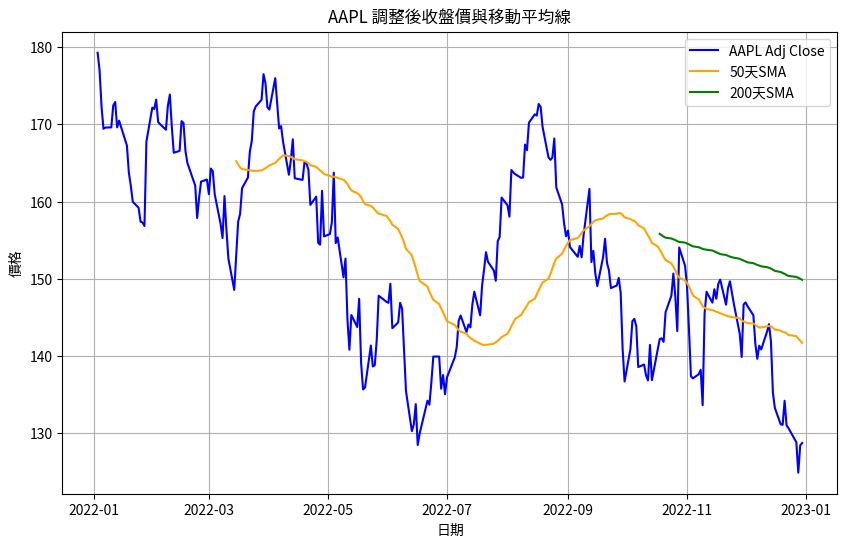

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(stock_data['Adj Close'], label='AAPL Adj Close', color='blue')
plt.plot(stock_data['SMA_50'], label='50天SMA', color='orange')
plt.plot(stock_data['SMA_200'], label='200天SMA', color='green')
plt.title('AAPL 調整後收盤價與移動平均線')
plt.xlabel('日期')
plt.ylabel('價格')
plt.legend()
plt.grid(True)
plt.show()

#### 3.2 視覺化 RSI
RSI 可以幫助你判斷超買或超賣的情況。當 RSI 大於 70 時，市場可能超買；當 RSI 小於 30 時，市場可能超賣。

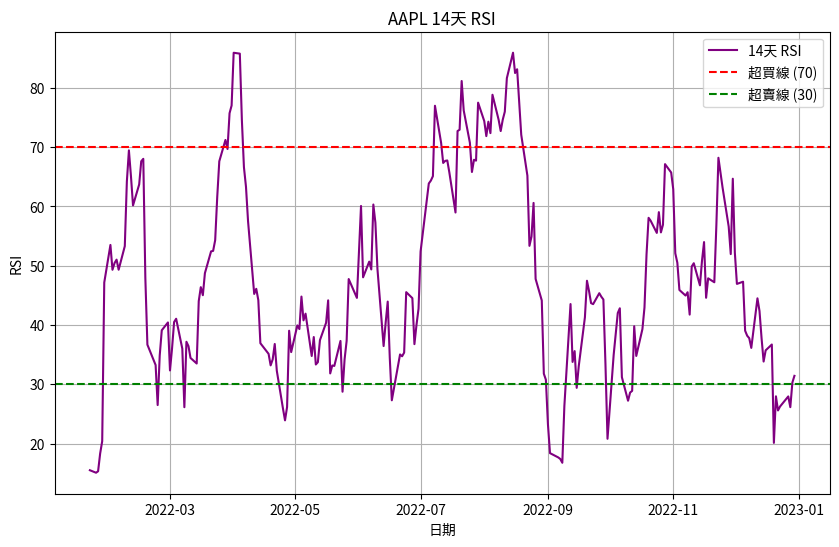

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(stock_data['RSI_14'], label='14天 RSI', color='purple')
plt.axhline(70, linestyle='--', color='red', label='超買線 (70)')
plt.axhline(30, linestyle='--', color='green', label='超賣線 (30)')
plt.title('AAPL 14天 RSI')
plt.xlabel('日期')
plt.ylabel('RSI')
plt.legend()
plt.grid(True)
plt.show()

#### 3.3 視覺化 MACD 與信號線
MACD 與信號線的交叉常常用作買入或賣出的信號。

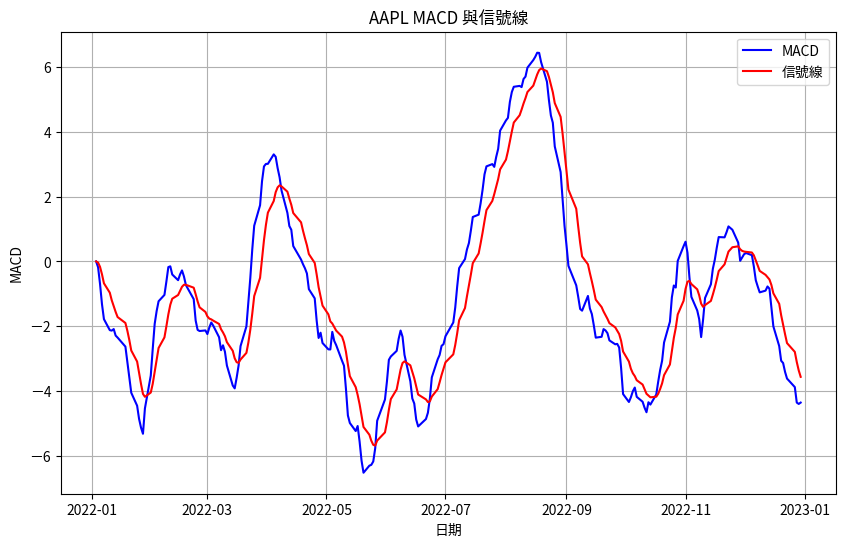

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(stock_data['MACD'], label='MACD', color='blue')
plt.plot(stock_data['Signal Line'], label='信號線', color='red')
plt.title('AAPL MACD 與信號線')
plt.xlabel('日期')
plt.ylabel('MACD')
plt.legend()
plt.grid(True)
plt.show()